# Using Y-factor to infer $T_{50 \Omega}$ of the blackbodies and noise diodes

Assuming our sources are perfect 50 $\Omega$ loads, we can use the hot-cold method to infer their effective noise temperature, assuming a linear response of power spectrum measured by the system (LNA and SA) to the input noise power. This procedure usually does not require a second-stage amplifier.

For a concise introduction to Y-factor noise figure measurements, see:
[Explore the Y-Factor Method for Noise Figure Measurement](https://www.allaboutcircuits.com/technical-articles/explore-the-y-factor-method-for-noise-figure-measurement/)

In [10]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from scipy.signal import medfilt
import matplotlib.pyplot as plt

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2

# import relevant classes from highz_exp
from highz_exp.fit_temperature import Y_Factor_Thermometer
from highz_exp.spec_class import Spectrum
from highz_exp.fit_model import CALModel, LNAModel
from highz_exp import plotter

# set up data paths
data_path = os.path.expanduser("~/Desktop/High-Z/SA_Measurements") # change this to your data directory
output_path = pjoin(data_path, 'Processed') # change this to your desired output directory
plot_path = pjoin(data_path, 'Plots') # change this to your desired plot directory
sparam_path = os.path.expanduser("~/Desktop/High-Z/S21Measurements") # change this to your S-parameter data directory

if os.path.exists(output_path) is False:
    os.makedirs(output_path)
if os.path.exists(plot_path) is False:
    os.makedirs(plot_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data loading procedure and required measurements

### Basic data-loading procedure
1. Set input/output paths (`data_path`, `output_path`, `plot_path`) and create output folders if needed.
2. Split each Keysight CSV export into:
   - a header table (`*_header.csv`)
   - a trace-data table (`*_data.csv`)
3. Parse the trace-data table into named traces (`Trace A`, `Trace B`, ...).
4. Wrap each trace as a `Spectrum` object with a meaningful label (for example `300K load - LNA01`, `ND01`, `BB014`).
5. Keep hot/cold reference traces and calibrator traces separate, because they are used in different steps:
   - hot/cold reference traces: estimate LNA gain and system temperature
   - calibrator traces: infer effective input temperaure of the blackbodies or noise diodes.

### Measurements required for this notebook
- **Required reference measurement set (for Y-factor calibration):**
  - 50 Ohm load near **300 K** (hot)
  - 50 Ohm load near **77 K** (cold)
  These two traces are mandatory to solve for system gain and `T_sys`.

- **Required calibrator measurement set (targets to characterize):**
  - Any blackbody/noise-diode traces you want to infer temperatures for (for example `BB013`, `BB014`, `BB016`, `ND01`, `ND02`).

- **Acquisition consistency requirements (important):**
  - Same RF chain/configuration (LNA, cables, SA settings)
  - Same RBW/channel width assumption used in conversion
  - Overlapping frequency coverage with sufficient SNR

In [11]:
# Import data loading module, this is used to parse CSV files from Keysight spectrum analyzer.
from highz_exp import load_csv

# load data for ND and BB measurements
file_ND = pjoin(data_path, 'LNA01_ND.csv')
file_BB = pjoin(data_path, 'LNA01_BB.csv')
load_csv.split_csv_by_trace_name(file_ND, 
                                 header_file=pjoin(output_path, 'LNA01_ND_header.csv'),
                                 data_file= pjoin(output_path, 'LNA01_ND_data.csv'))
load_csv.split_csv_by_trace_name(file_BB, 
                                 header_file=pjoin(output_path, 'LNA01_BB_header.csv'),
                                 data_file= pjoin(output_path, 'LNA01_BB_data.csv'))

# parse data files into separate traces
traces_LNA = load_csv.parse_trace_data(pjoin(output_path, 'LNA01_BB_data.csv'))
LNA01_300K = Spectrum(traces_LNA['Trace A']['frequency'], traces_LNA['Trace A']['spectrum'], 
                      name='300K load - LNA01')
LNA01_77K = Spectrum(traces_LNA['Trace D']['frequency'], traces_LNA['Trace D']['spectrum'], 
                     name='77K load - LNA01')

# load traces for all the other three measurements (ND01, ND02, BB014)
traces_ND = load_csv.parse_trace_data(pjoin(output_path, 'LNA01_ND_data.csv'))
LNA01_BB014 = Spectrum(traces_ND['Trace A']['frequency'], traces_ND['Trace A']['spectrum'], name='BB014')
LNA01_ND01 = Spectrum(traces_ND['Trace B']['frequency'], traces_ND['Trace B']['spectrum'], name='ND01')
LNA01_ND02 = Spectrum(traces_ND['Trace C']['frequency'], traces_ND['Trace C']['spectrum'], name='ND02')

Split complete:
  Header file: /Users/yuntongzhou/Desktop/High-Z/SA_Measurements/Processed/LNA01_ND_header.csv (30 rows)
  Data file: /Users/yuntongzhou/Desktop/High-Z/SA_Measurements/Processed/LNA01_ND_data.csv (755 rows)
Split complete:
  Header file: /Users/yuntongzhou/Desktop/High-Z/SA_Measurements/Processed/LNA01_BB_header.csv (30 rows)
  Data file: /Users/yuntongzhou/Desktop/High-Z/SA_Measurements/Processed/LNA01_BB_data.csv (755 rows)
Found 4 traces: ['Trace A', 'Trace B', 'Trace C', 'Trace D']
Column pairs: [(0, 1), (2, 3), (4, 5), (6, 7)]
'Trace Data' found at row 3
Trace 'Trace A': parsed 751 data points
Trace 'Trace B': parsed 751 data points
Trace 'Trace C': parsed 751 data points
Trace 'Trace D': parsed 751 data points
Successfully parsed 4 traces with data
Found 4 traces: ['Trace A', 'Trace B', 'Trace C', 'Trace D']
Column pairs: [(0, 1), (2, 3), (4, 5), (6, 7)]
'Trace Data' found at row 3
Trace 'Trace A': parsed 751 data points
Trace 'Trace B': parsed 751 data points
Tra

We need to calculate the system gain and noise temperature first, with 77 Kelvin and 300 Kelvin 50 Ohm loads as the hot and cold sources. To do this, we first convert all the measurements from log scale to linear scale. 

Here we'll use a `Y_Factor_Thermometer` class from the `highz_exp` package, which has the functionalities to calculate and plot the noise temperature and gain of the LNA based on the hot-cold measurements.

In [100]:
# Convert the hot-cold measurements from dBm to milliwatt
dut_hot = LNA01_300K.unit_convert('dBm', 'milliwatt', channel_width=1e6).spec
dut_cold = LNA01_77K.unit_convert('dBm', 'milliwatt', channel_width=1e6).spec

# construct the Y-Factor thermometer object, 
# this has the functionalities to calculate and plot the noise temperature and gain of the LNA 
# based on the hot-cold measurements
LNA_thermo = Y_Factor_Thermometer(LNA01_300K.freq, dut_hot, dut_cold,
            DUT_name='LNA01', T_hot=301, T_cold=77, RBW=1e6)

# smooth gain with median filter
LNA_thermo.g = medfilt(LNA_thermo.g, kernel_size=11)
LNA_thermo.T_sys = medfilt(LNA_thermo.T_sys, kernel_size=11)

# Reduce sampling to 2 MHz bin
new_frequency = np.arange(20e6, 250e6, 100e3)  # New frequency axis from 20 MHz to 400 MHz with 2 MHz spacing
LNA_thermo_resampled = LNA_thermo.resample(new_frequency, reducer=np.nanmedian, inplace=False)

[ 1.00000000e+03  1.11040512e+10 -1.09800610e+07 -1.23401243e+01
  5.38720477e-07]
0.9987419216689852


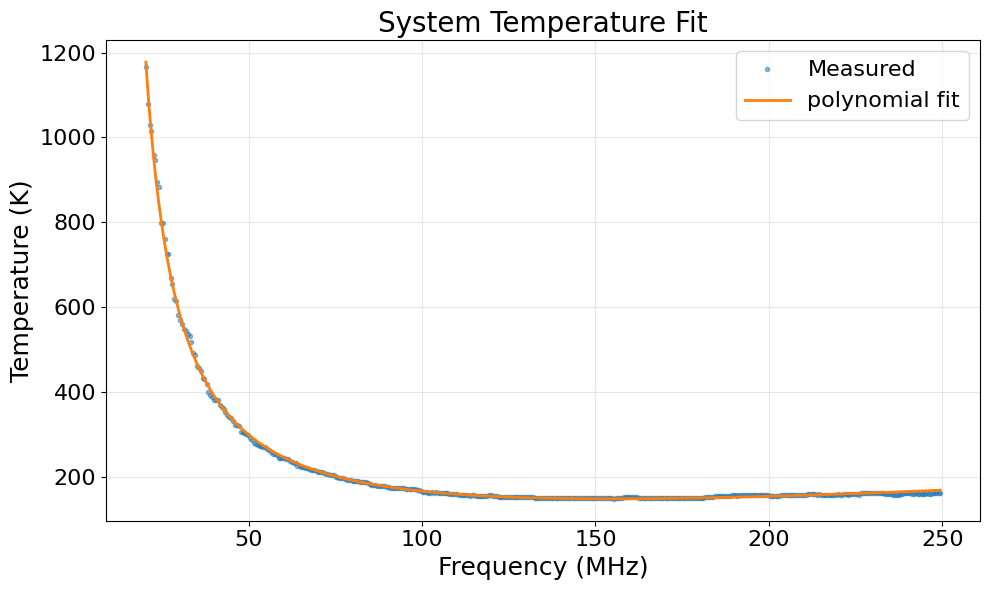

In [101]:
# Fit T(f) = a/f + b + c*f to the LNA temperature curve
f_fit = np.asarray(LNA_thermo_resampled.f, dtype=float)  # Hz
t_fit = np.asarray(LNA_thermo_resampled.T_dut if LNA_thermo_resampled.T_dut is not None else LNA_thermo_resampled.T_sys, dtype=float)
fit_res = LNAModel.fit_temperature(f_fit, t_fit, initial_guess=[1e3, 1.1e10, 1*10**(-7), 3, 4e-8])

valid = fit_res['valid_mask']
f_valid_hz = f_fit[valid]
t_valid = t_fit[valid]
print(fit_res['coefficients'])
print(fit_res['r2'])
t_model = fit_res['fitted']

plt.figure(figsize=(10, 6))
plt.plot(f_valid_hz / 1e6, t_valid, 'o', ms=3, alpha=0.5, label='Measured')
plt.plot(f_valid_hz / 1e6, t_model, '-', lw=2, label='polynomial fit')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('System Temperature Fit')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[-9.54469814e+00  1.07765500e-06 -2.77929343e-14  4.72772386e-22
 -5.31607330e-30  3.91386488e-38 -1.85488945e-46  5.43131105e-55
 -8.91810703e-64  6.26960717e-73]


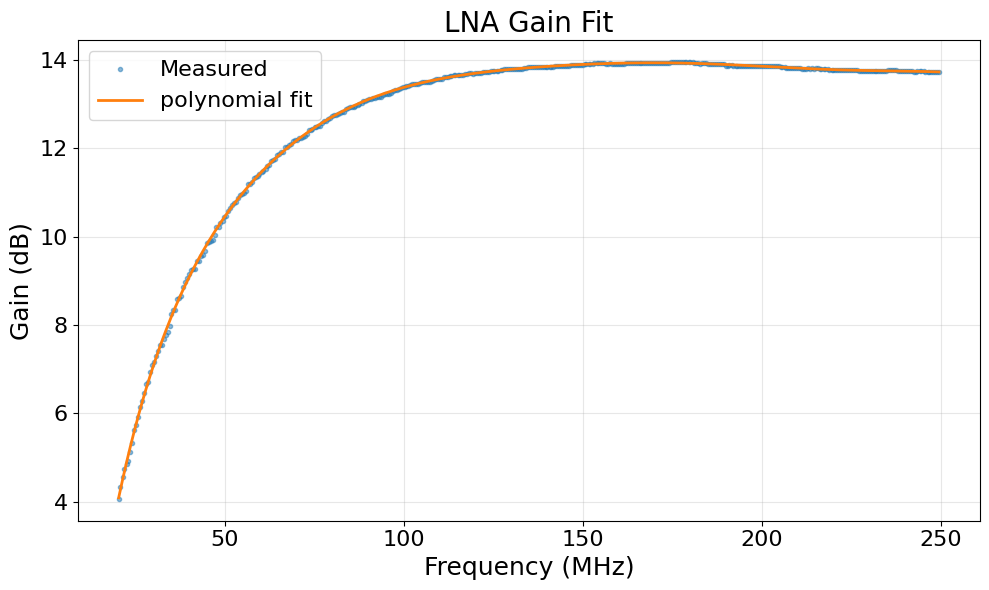

In [102]:
LNA_thermo_resampled.T_sys = t_model

f_fit = np.asarray(LNA_thermo_resampled.f, dtype=float)  # Hz
g_fit = np.asarray(LNA_thermo_resampled.g, dtype=float)

fit_res = LNAModel.fit_gain(f_fit, g_fit, order=9)

valid = fit_res['valid_mask']
f_valid_hz = f_fit[valid]
g_valid = g_fit[valid]
print(fit_res['coefficients'])
g_model = fit_res['fitted']

plt.figure(figsize=(10, 6))
plt.plot(f_valid_hz / 1e6, g_valid, 'o', ms=3, alpha=0.5, label='Measured')
plt.plot(f_valid_hz / 1e6, g_model, '-', lw=2, label='polynomial fit')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Gain (dB)')
plt.title('LNA Gain Fit')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

LNA_thermo_resampled.g = g_model
LNA_thermo_resampled.f = f_valid_hz

From the measured power spectrum of the calibrators loads after LNA, we can infer their input temperature.

In [103]:
# Convert all measurements from dBm to kelvin for comparison
# and resample them to the same frequency grid
ND01_spec = LNA01_ND01.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False).median_smooth(11, inplace=False).resample(new_frequency)
ND02_spec = LNA01_ND02.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False).median_smooth(11, inplace=False).resample(new_frequency)

ND01_kelvin = LNA_thermo_resampled.infer_temperature(ND01_spec.despike(threshold=3), show_plot=False)
ND02_kelvin = LNA_thermo_resampled.infer_temperature(ND02_spec.despike(threshold=3), show_plot=False)

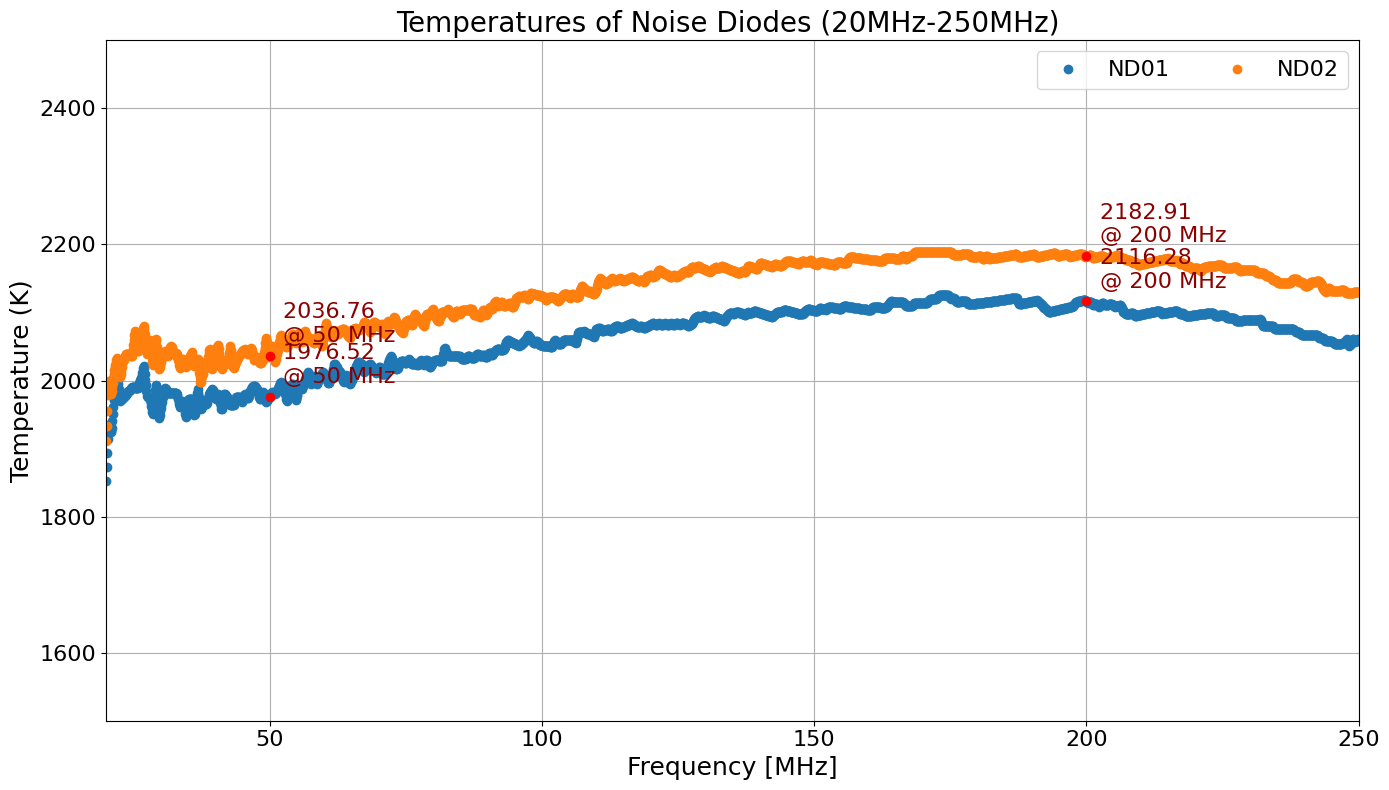

In [104]:
plotter.plot_spectra([ND01_kelvin, ND02_kelvin], title='Temperatures of Noise Diodes (20MHz-250MHz) ',
                     ylabel='Temperature (K)', y_range=(1500, 2500),
                     freq_range=(20, 250), marker='o', linestyle='',
                     marker_freqs=(50, 200),
                     save_path=pjoin(plot_path, 'Cal_Temperature.png'))

[1.96174129e+03 8.91468075e-07]
0.9069906404484236


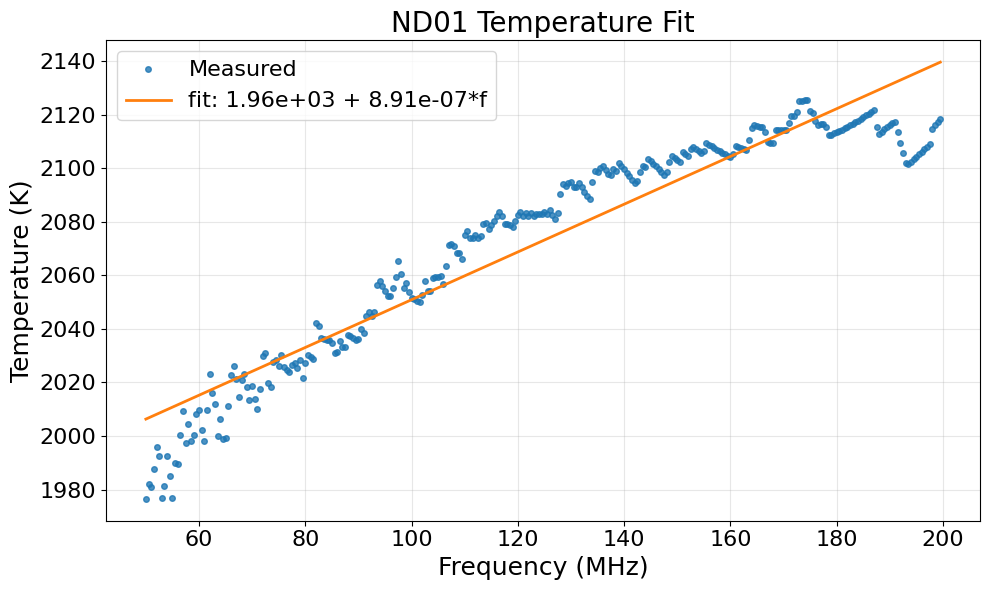

In [105]:
new_frequency = np.arange(50e6, 200e6, 500e3)  # New frequency axis from 20 MHz to 400 MHz with 2 MHz spacing
ND01_kelvin.resample(new_frequency, reducer=np.nanmedian, inplace=True)

fitted = CALModel.fit_temperature(ND01_kelvin.f, ND01_kelvin.spec, order=1)

valid = fitted['valid_mask']
f_valid_hz = ND01_kelvin.f[valid]
t_valid = ND01_kelvin.spec[valid]
print(fitted['coefficients'])
print(fitted['r2'])
t_model = fitted['fitted']
fit_equation = f"{fitted['coefficients'][0]:.2e} + {fitted['coefficients'][1]:.2e}*f"

plt.figure(figsize=(10, 6))
plt.plot(f_valid_hz / 1e6, t_valid, 'o', ms=4, alpha=0.8, label='Measured')
plt.plot(f_valid_hz / 1e6, t_model, '-', lw=2, label=f'fit: {fit_equation}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('ND01 Temperature Fit')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(pjoin(plot_path, 'ND01_T_fit.png'))
plt.show()

[ 1.99525377e+03  8.74667584e-07  7.49426227e-15 -3.57570686e-23]
0.9730419583553174


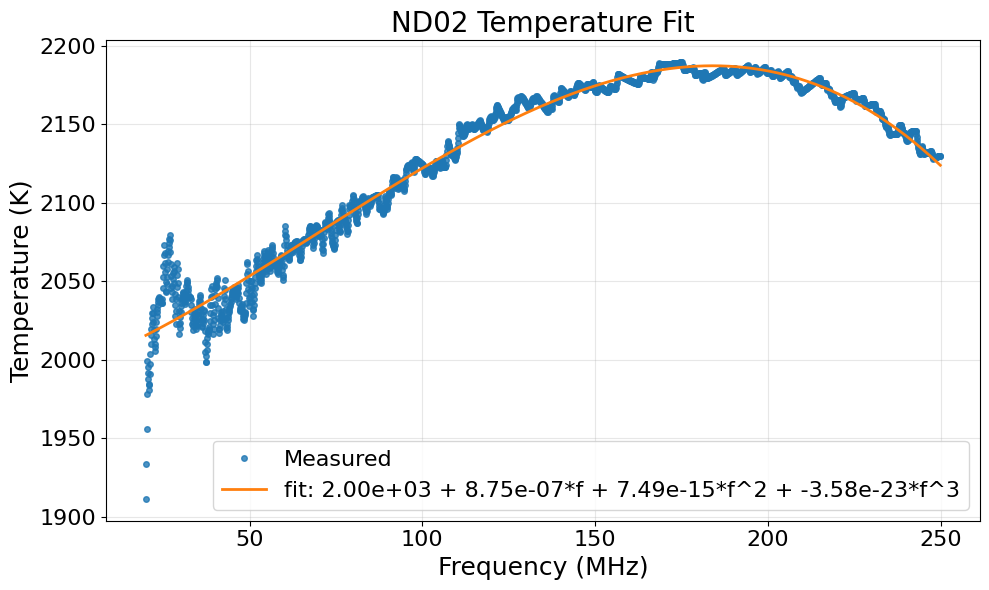

In [106]:
fitted = CALModel.fit_temperature(ND02_kelvin.f, ND02_kelvin.spec, order=3)

valid = fitted['valid_mask']
f_valid_hz = ND02_kelvin.f[valid]
t_valid = ND02_kelvin.spec[valid]
print(fitted['coefficients'])
print(fitted['r2'])
t_model = fitted['fitted']
fit_equation = f"{fitted['coefficients'][0]:.2e} + {fitted['coefficients'][1]:.2e}*f + {fitted['coefficients'][2]:.2e}*f^2 + {fitted['coefficients'][3]:.2e}*f^3"

plt.figure(figsize=(10, 6))
plt.plot(f_valid_hz / 1e6, t_valid, 'o', ms=4, alpha=0.8, label='Measured')
plt.plot(f_valid_hz / 1e6, t_model, '-', lw=2, label=f'fit: {fit_equation}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('ND02 Temperature Fit')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(pjoin(plot_path, 'ND02_T_fit.png'))
plt.show()